# Урок 8. Деревья решений.

В уроках мы разбирали на небольшом наборе данных деревья решений без настройки гиперпараметров. Здесь предлагаем вам рассмотреть работу классификатора на более сложном датасете, применив настройку гиперпараметров.

### 1.
На датасете из предыдущего урока - load_wine() - обучите дерево решений (DecisionTreeClassifier).

*Примечание: при установке гиперпараметров модели и разбиении на тренировочный и тестовый датасеты используйте random_state=17 для воспроизводимости результатов.*

In [2]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
wine_dataset = load_wine()
wine_dataset['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [4]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(wine_dataset.data[:, [0,6]], 
                                                    wine_dataset['target'],
                                                    random_state=17) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (133, 2), y_train shape: (133,),
X_test shape: (45, 2), y_test shape: (45,)


In [7]:
dtc_model = dtc.fit(x_train, y_train)

### 2.
Отобразите дерево с помощью библиотеки graphviz.

*Примечание: если, изучая урок, вы не установили библиотеку graphviz, то необходимо сделать это сейчас.*

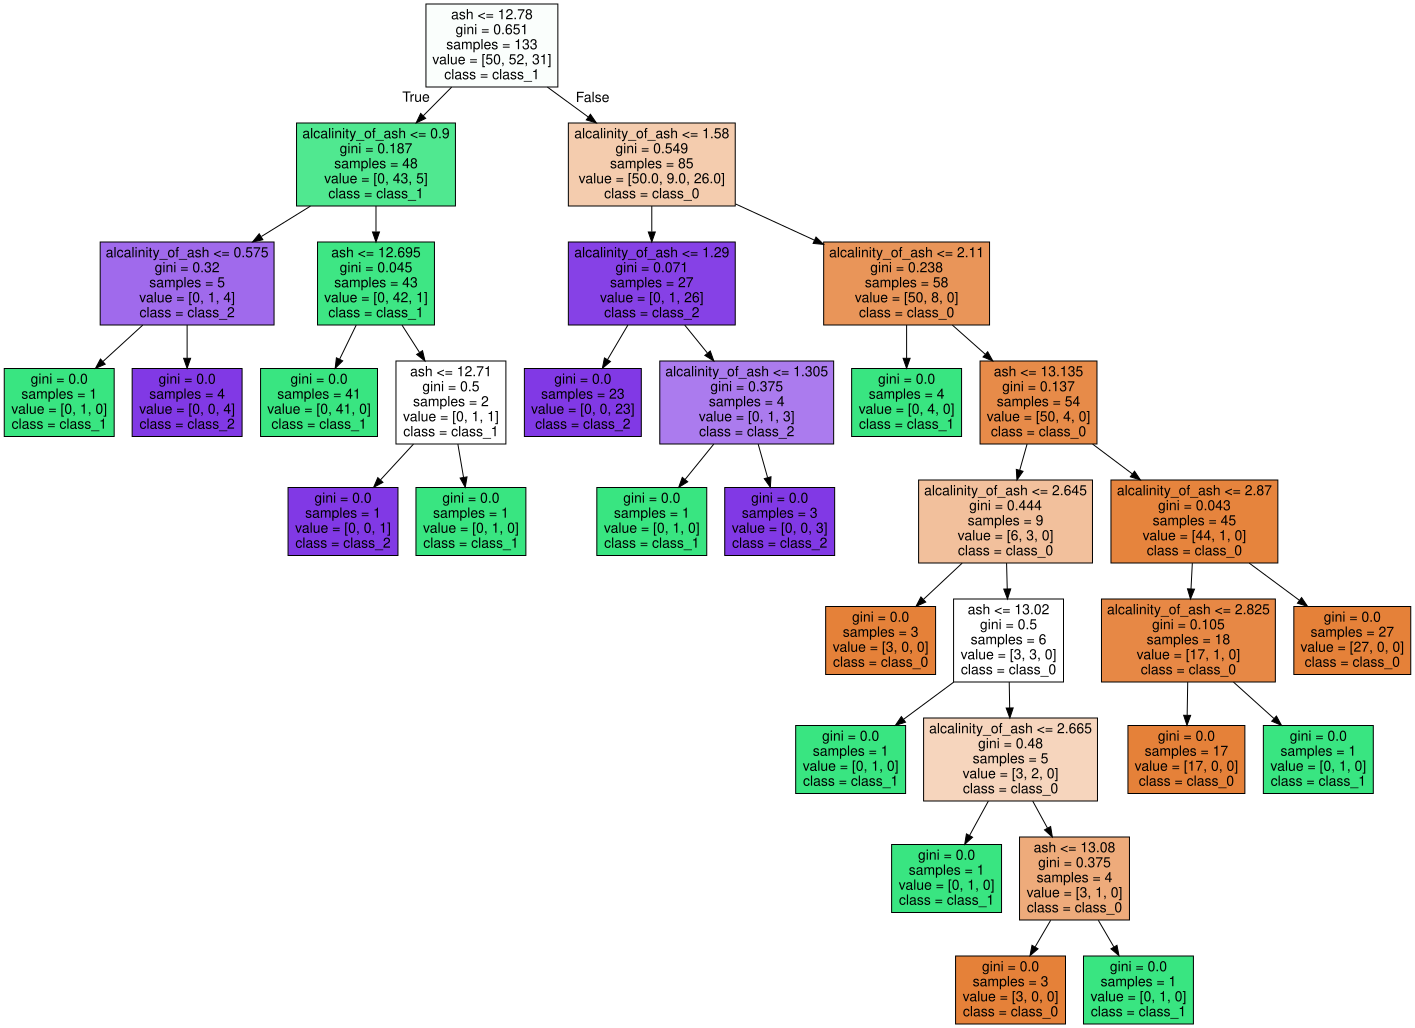

In [8]:
from sklearn import tree
import graphviz

def print_graph(data):
    dot_data = tree.export_graphviz(data, out_file=None,
                                    feature_names=wine_dataset.feature_names[2:4],
                                    class_names=wine_dataset.target_names,
                                    filled=True)
    return graphviz.Source(dot_data)

print_graph(dtc_model)

### 3.
Используя полученную модель, сделайте прогноз для тестовой выборки данных и, пользуясь встроенной функцией score(), определите точность модели.

In [9]:
dtc_predictions = dtc.predict(x_test)

In [10]:
accuracy = dtc.score(x_test, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8888888888888888


Теперь попробуем сделать начальную настройку гиперпараметров и посмотреть, что из этого выйдет.

### 4.

Постройте модель, указав гиперпараметр max_features равным 2 (так же указав random_state=17) и, сделав прогноз на тестовых данных, определите, стала ли модель работать точнее.

*Примечание: гиперпараметр max_features показывает модели, сколько различных признаков необходимо использовать каждый раз при принятии решения о разделении. То есть если, допустим, у вас имеются 50 признаков, а max_features=10, то в каждом узле случайным образом выбираются 10 признаков, которые будут использоваться для поиска лучшего разделения.*

In [12]:
dtc_max_features = DecisionTreeClassifier(max_features=2, random_state=17)
dtc_model_max_features = dtc_max_features.fit(x_train, y_train)
dtc_predictions_max_features = dtc_max_features.predict(x_test)
accuracy = dtc_max_features.score(x_test, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8888888888888888


In [13]:
dtc_max_features = DecisionTreeClassifier(max_features=10, random_state=17)
dtc_model_max_features = dtc_max_features.fit(x_train, y_train)
dtc_predictions_max_features = dtc_max_features.predict(x_test)
accuracy = dtc_max_features.score(x_test, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8888888888888888


In [ ]:
#вывод: при увеличении признаков для поиска лучшего разделителя, точность модели остается прежней

### 5.
Теперь постройте граф дерева решений, используя graphviz.

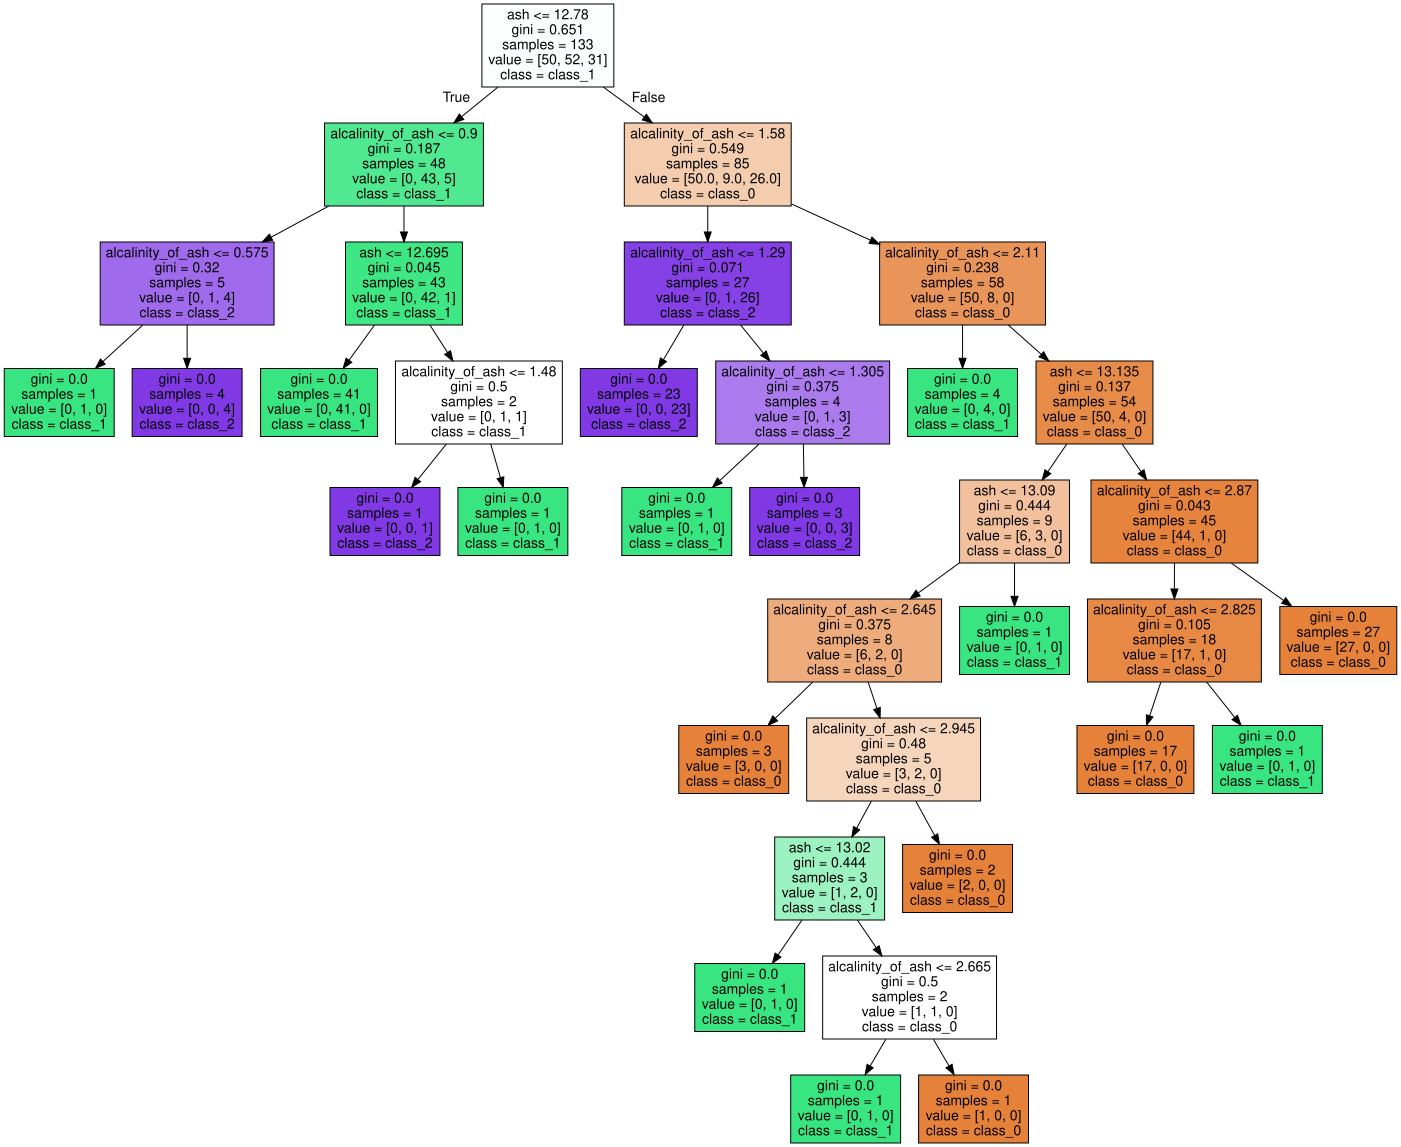

In [14]:
print_graph(dtc_model_max_features)

Модель работает точнее, чем без настройки гиперпараметров, но по графу можно увидеть, что глубина дерева увеличилась, при этом в нескольких листах присутствует только по одному объекту, из-за чего на тестовом наборе данных дерево могло несколько потерять обобщающую способность.

Так как главная задача модели - способность обобщаться на новые данные, то для подбора оптимальных гиперпараметров надо пожертвовать небольшой порцией данных, чтобы на ней во время обучения проверять качество модели.

Часто для этого используют кросс-валидацию: модель обучается K раз на (K-1) подвыборках исходной выборки, а на одной подвыборке проверяется (каждый раз на разной). Получаются K оценок качества модели, которые обычно усредняются, давая среднюю оценку.

Кросс-валидация применяется для подбора гиперпараметров модели в методе GridSearchCV(): для каждой уникальной совокупности значений параметров проводится кросс-валидация и выбирается лучшее сочетание параметров.

### 6.
Используя обученное в предыдущем задании дерево решений, настройте параметры max_depth и max_features на 5-кратной валидации с помощью GridSearchCV. Для этого в функцию GridSearchCV передайте параметры (tree, tree_params, cv=5).

*Примечание: tree здесь - не обученная модель, а объект, который инкапсулирует алгоритм. Например, в уроке мы его обозначали как dtc.*

In [15]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [27]:
dtc_new = DecisionTreeClassifier(random_state=17)
tree_params = {'max_depth': range(1, 6),
               'max_features': range(1, 10)}

#создаем объект GridSearchCV
tree_grid = GridSearchCV(dtc_new, tree_params, cv=5)


### 7.
С помощью метода tree_grid.fit() постройте модель на тренировочных данных и выведите лучшее сочетание параметров с помощью метода tree_grid.best_params_.

In [28]:
#обучаем GridSearch на тренировочных данных
tree_grid.fit(x_train, y_train)
#смотрим лучшие параметры и лучшую модель
print("Лучшие параметры:", tree_grid.best_params_)

Лучшие параметры: {'max_depth': 3, 'max_features': 2}


### 8.
С помощью полученной модели сделайте прогноз - predict - для тестовой выборки и выведите долю верных ответов, проверив точность модели, используя функцию accuracy_score.

In [19]:
from sklearn.metrics import accuracy_score

In [29]:
predicted = tree_grid.best_estimator_
predictions = predicted.predict(x_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy на тесте: {accuracy}')

Accuracy на тесте: 0.9111111111111111
